## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"C:\Users\DIVYA BASANTRAY\lending_club_selected.csv"

df = pd.read_csv(file_path, low_memory=False)

## DATA QUALITY CHECKS

In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2260701, 27)


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,delinq_2yrs,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,recoveries
0,68407277,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,0.0,675.0,679.0,7.0,0.0,2765.0,29.7,13.0,4421.723917,0.0
1,68355089,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,1.0,715.0,719.0,22.0,0.0,21470.0,19.2,38.0,25679.660000,0.0
2,68341763,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,0.0,695.0,699.0,6.0,0.0,7869.0,56.2,18.0,22705.924294,0.0
3,66310712,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,...,0.0,785.0,789.0,13.0,0.0,7802.0,11.6,17.0,31464.010000,0.0
4,68476807,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,1.0,695.0,699.0,12.0,0.0,21929.0,64.5,35.0,11740.500000,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 27 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id                   object 
 1   loan_amnt            float64
 2   funded_amnt          float64
 3   term                 object 
 4   int_rate             float64
 5   installment          float64
 6   grade                object 
 7   sub_grade            object 
 8   emp_length           object 
 9   home_ownership       object 
 10  annual_inc           float64
 11  verification_status  object 
 12  issue_d              object 
 13  loan_status          object 
 14  purpose              object 
 15  addr_state           object 
 16  dti                  float64
 17  delinq_2yrs          float64
 18  fico_range_low       float64
 19  fico_range_high      float64
 20  open_acc             float64
 21  pub_rec              float64
 22  revol_bal            float64
 23  revol_util           float64
 24

In [5]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[
    missing_values["Missing_Count"] > 0
].sort_values(by="Missing_Percentage", ascending=False)

missing_values

,Missing_Count,Missing_Percentage
emp_length,146940,6.499754
revol_util,1835,0.081170
dti,1744,0.077144
open_acc,62,0.002743
delinq_2yrs,62,0.002743
pub_rec,62,0.002743
total_acc,62,0.002743
annual_inc,37,0.001637
funded_amnt,33,0.001460
loan_amnt,33,0.001460


In [6]:
print("Total Duplicate Rows:", df.duplicated().sum())

print("Duplicate Loan IDs:", df["id"].duplicated().sum())

Total Duplicate Rows: 0
Duplicate Loan IDs: 0


## LOAN STATUS DISTRIBUTION

In [7]:
df["loan_status"].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

## LOAN STATUS PERCENTAGES

In [8]:
loan_status_summary = pd.DataFrame({
    "Loan_Count": df["loan_status"].value_counts(dropna=False),
    "Percentage": (
        df["loan_status"].value_counts(normalize=True, dropna=False) * 100
    )
})

loan_status_summary

,Loan_Count,Percentage
loan_status,,
Fully Paid,1076751,47.629076
Current,878317,38.851533
Charged Off,268559,11.879457
Late (31-120 days),21467,0.949573
In Grace Period,8436,0.373159
Late (16-30 days),4349,0.192374
Does not meet the credit policy. Status:Fully Paid,1988,0.087937
Does not meet the credit policy. Status:Charged Off,761,0.033662
Default,40,0.001769


## COMPARING TWO MAIN OUTCOMES

In [9]:
main_outcomes = df[
    df["loan_status"].isin(["Fully Paid", "Charged Off"])
]

main_outcomes["loan_status"].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

## CREATING THE RESOLVED-LOAN DATASET

In [10]:
# Keeping only loans with one of the two main resolved outcomes
resolved_loans = df[
    df["loan_status"].isin(["Fully Paid", "Charged Off"])
].copy()

print("Resolved Loans Shape:", resolved_loans.shape)

resolved_loans["loan_status"].value_counts()

Resolved Loans Shape: (1345310, 27)


loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

## CALCULATION OF THE INITIAL CHARGED-OFF RATE

In [11]:
total_resolved = len(resolved_loans)

charged_off_count = (
    resolved_loans["loan_status"] == "Charged Off"
).sum()

fully_paid_count = (
    resolved_loans["loan_status"] == "Fully Paid"
).sum()

charged_off_rate = (charged_off_count / total_resolved) * 100

print("Total Resolved Loans:", total_resolved)
print("Fully Paid Loans:", fully_paid_count)
print("Charged Off Loans:", charged_off_count)
print(f"Charged-Off Rate: {charged_off_rate:.2f}%")

Total Resolved Loans: 1345310
Fully Paid Loans: 1076751
Charged Off Loans: 268559
Charged-Off Rate: 19.96%


## CREATING THE TARGET VARIABLE

In [12]:
# Creating a separate copy for analysis
resolved_loans = resolved_loans.copy()

# 1 = Charged Off, 0 = Fully Paid
resolved_loans["default_flag"] = (
    resolved_loans["loan_status"] == "Charged Off"
).astype(int)

resolved_loans[["loan_status", "default_flag"]].head(10)

,loan_status,default_flag
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0
6,Fully Paid,0
7,Fully Paid,0
8,Fully Paid,0
9,Fully Paid,0
12,Fully Paid,0


## VALIDATING THE TARGET VARIABLE

In [13]:
print(resolved_loans["default_flag"].value_counts())

print("\nDefault Rate by Flag:")
print(resolved_loans.groupby("default_flag")["id"].count())

default_flag
0    1076751
1     268559
Name: count, dtype: int64

Default Rate by Flag:
default_flag
0    1076751
1     268559
Name: id, dtype: int64


## CALCULATION OF DEFAULT RATE BY GRADE

In [14]:
grade_analysis = (
    resolved_loans.groupby("grade")
    .agg(
        Total_Loans=("default_flag", "count"),
        Charged_Off_Loans=("default_flag", "sum"),
        Default_Rate=("default_flag", "mean")
    )
    .reset_index()
)

grade_analysis["Default_Rate"] = (
    grade_analysis["Default_Rate"] * 100
).round(2)

grade_analysis = grade_analysis.sort_values("grade")

grade_analysis

,grade,Total_Loans,Charged_Off_Loans,Default_Rate
0,A,235090,14201,6.04
1,B,392741,52569,13.39
2,C,381686,85649,22.44
3,D,200953,61054,30.38
4,E,93650,36035,38.48
5,F,32058,14491,45.20
6,G,9132,4560,49.93


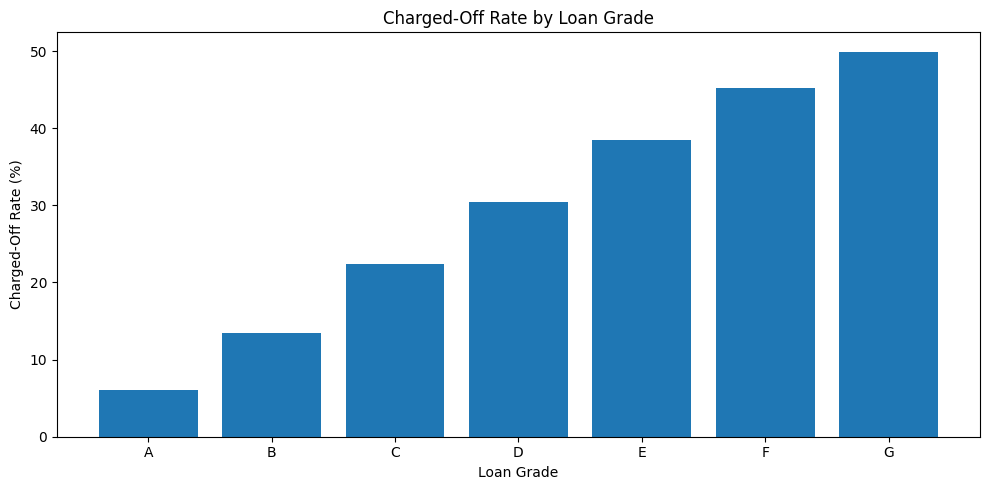

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    grade_analysis["grade"],
    grade_analysis["Default_Rate"]
)

plt.title("Charged-Off Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Charged-Off Rate (%)")

plt.tight_layout()
plt.show()

## CREATING INTEREST-RATE GROUPS

In [17]:
rate_bins = [0, 5, 10, 15, 20, 25, 30, 35]

rate_labels = [
    "0-5%",
    "5-10%",
    "10-15%",
    "15-20%",
    "20-25%",
    "25-30%",
    "30-35%"
]

resolved_loans["interest_rate_band"] = pd.cut(
    resolved_loans["int_rate"],
    bins=rate_bins,
    labels=rate_labels,
    right=False
)

resolved_loans["interest_rate_band"].value_counts(
    sort=False,
    dropna=False
)

interest_rate_band
0-5%           0
5-10%     375282
10-15%    554212
15-20%    305672
20-25%     83813
25-30%     21629
30-35%      4702
Name: count, dtype: int64

## CALCULATION OF CHARGED-OFF RATE BY INTEREST-RATE BAND

In [18]:
interest_rate_analysis = (
    resolved_loans.groupby("interest_rate_band", observed=False)
    .agg(
        Total_Loans=("default_flag", "count"),
        Charged_Off_Loans=("default_flag", "sum"),
        Default_Rate=("default_flag", "mean")
    )
    .reset_index()
)

interest_rate_analysis["Default_Rate"] = (
    interest_rate_analysis["Default_Rate"] * 100
).round(2)

interest_rate_analysis

,interest_rate_band,Total_Loans,Charged_Off_Loans,Default_Rate
0,0-5%,0,0,NaN
1,5-10%,375282,30626,8.16
2,10-15%,554212,102997,18.58
3,15-20%,305672,90172,29.50
4,20-25%,83813,32177,38.39
5,25-30%,21629,10282,47.54
6,30-35%,4702,2305,49.02


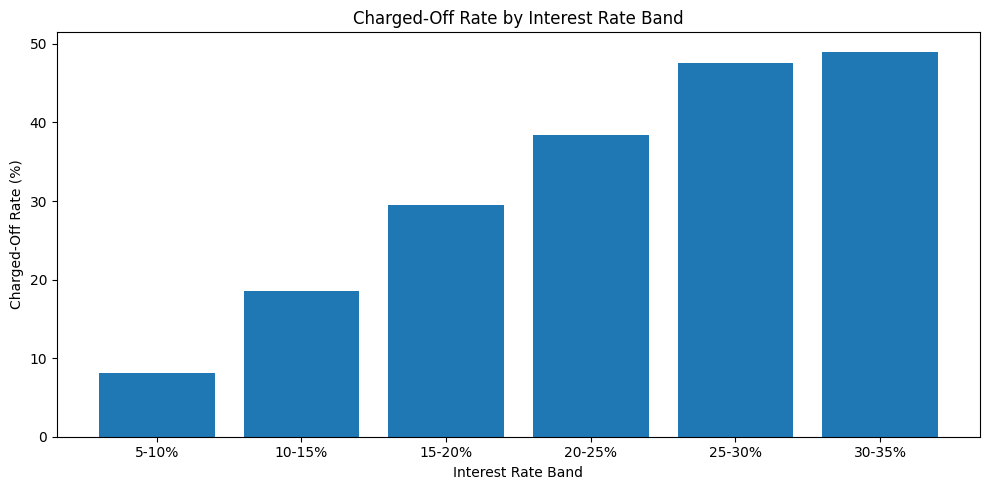

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    interest_rate_analysis["interest_rate_band"].astype(str),
    interest_rate_analysis["Default_Rate"]
)

plt.title("Charged-Off Rate by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Charged-Off Rate (%)")

plt.tight_layout()
plt.show()

## CALCULATION OF CHARGED-OFF RATE BY LOAN TERM

In [20]:
term_analysis = (
    resolved_loans.groupby("term")
    .agg(
        Total_Loans=("default_flag", "count"),
        Charged_Off_Loans=("default_flag", "sum"),
        Default_Rate=("default_flag", "mean")
    )
    .reset_index()
)

term_analysis["Default_Rate"] = (
    term_analysis["Default_Rate"] * 100
).round(2)

term_analysis

,term,Total_Loans,Charged_Off_Loans,Default_Rate
0,36 months,1020743,163252,15.99
1,60 months,324567,105307,32.45


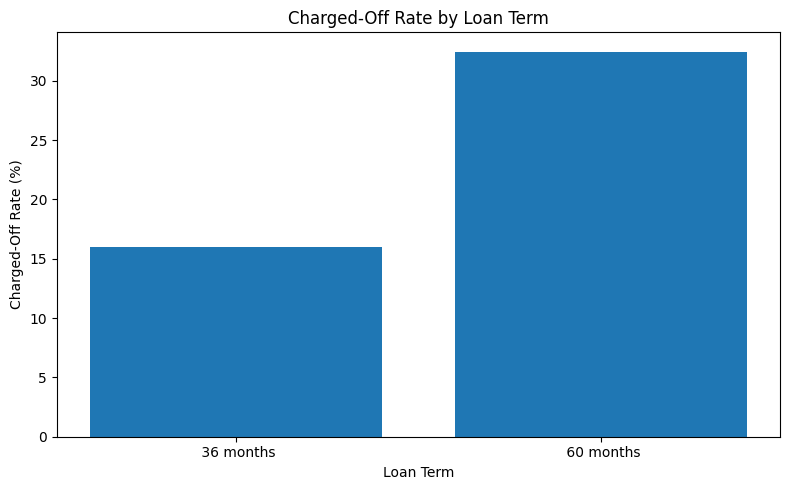

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    term_analysis["term"],
    term_analysis["Default_Rate"]
)

plt.title("Charged-Off Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Charged-Off Rate (%)")

plt.tight_layout()
plt.show()

## CHECKING ANNUAL INCOME DISTRIBUTION FIRST

In [22]:
resolved_loans["annual_inc"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.345310e+06
mean     7.624764e+04
std      6.992510e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
90%      1.250000e+05
95%      1.550000e+05
99%      2.500000e+05
max      1.099920e+07
Name: annual_inc, dtype: float64

## CHECKING ZERO AND MISSING INCOME VALUES

In [23]:
print("Missing Annual Income:", resolved_loans["annual_inc"].isna().sum())

print("Zero Annual Income:", (resolved_loans["annual_inc"] == 0).sum())

print("Negative Annual Income:", (resolved_loans["annual_inc"] < 0).sum())

Missing Annual Income: 0
Zero Annual Income: 361
Negative Annual Income: 0


## CREATING INCOME BANDS

In [24]:
income_bins = [
    -0.1, 0, 25000, 50000, 75000,
    100000, 150000, 250000, float("inf")
]

income_labels = [
    "$0",
    "$1-$25K",
    "$25K-$50K",
    "$50K-$75K",
    "$75K-$100K",
    "$100K-$150K",
    "$150K-$250K",
    "Above $250K"
]

resolved_loans["income_band"] = pd.cut(
    resolved_loans["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    right=True
)

resolved_loans["income_band"].value_counts(
    sort=False,
    dropna=False
)

income_band
$0                361
$1-$25K         51140
$25K-$50K      381508
$50K-$75K      411901
$75K-$100K     250359
$100K-$150K    178919
$150K-$250K     57675
Above $250K     13447
Name: count, dtype: int64

## CALCULATION OF CHARGED-OFF RATES BY INCOME BAND

In [25]:
income_analysis = (
    resolved_loans.groupby("income_band", observed=False)
    .agg(
        Total_Loans=("default_flag", "count"),
        Charged_Off_Loans=("default_flag", "sum"),
        Default_Rate=("default_flag", "mean")
    )
    .reset_index()
)

income_analysis["Default_Rate"] = (
    income_analysis["Default_Rate"] * 100
).round(2)

income_analysis

,income_band,Total_Loans,Charged_Off_Loans,Default_Rate
0,$0,361,68,18.84
1,$1-$25K,51140,12515,24.47
2,$25K-$50K,381508,86601,22.70
3,$50K-$75K,411901,84365,20.48
4,$75K-$100K,250359,45701,18.25
5,$100K-$150K,178919,28943,16.18
6,$150K-$250K,57675,8618,14.94
7,Above $250K,13447,1748,13.00


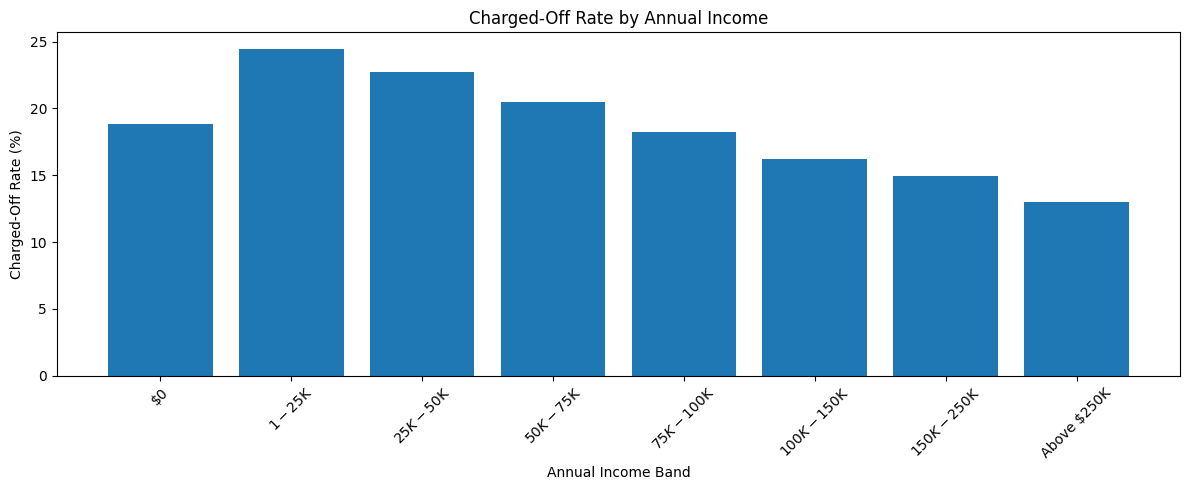

In [26]:
plt.figure(figsize=(12, 5))

plt.bar(
    income_analysis["income_band"].astype(str),
    income_analysis["Default_Rate"]
)

plt.title("Charged-Off Rate by Annual Income")
plt.xlabel("Annual Income Band")
plt.ylabel("Charged-Off Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## CHECKING DTI DISTRIBUTION

In [27]:
resolved_loans["dti"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.344936e+06
mean     1.828267e+01
std      1.116045e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
90%      2.978000e+01
95%      3.299000e+01
99%      3.847000e+01
max      9.990000e+02
Name: dti, dtype: float64

## COUNTING UNUSUAL DTI VALUES

In [28]:
print("Negative DTI values:", (resolved_loans["dti"] < 0).sum())

print("DTI equal to 999:", (resolved_loans["dti"] == 999).sum())

print("DTI above 100:", (resolved_loans["dti"] > 100).sum())

print("\nMost frequent DTI values:")
print(resolved_loans["dti"].value_counts().head(15))

Negative DTI values: 2
DTI equal to 999: 38
DTI above 100: 533

Most frequent DTI values:
dti
18.00    995
19.20    991
14.40    971
16.80    951
15.60    918
13.20    915
12.00    898
20.40    872
0.00     859
21.60    849
10.80    808
22.80    798
24.00    773
16.32    755
16.20    754
Name: count, dtype: int64


## INSPECTING RECORDS WITH UNUSUAL DTI

In [29]:
resolved_loans.loc[
    (resolved_loans["dti"] < 0) | (resolved_loans["dti"] > 100),
    ["id", "annual_inc", "dti", "loan_status"]
].head(20)

,id,annual_inc,dti,loan_status
8721,67405134,1770.00,999.00,Fully Paid
10548,67555887,20000.00,137.40,Fully Paid
22841,66495833,27000.00,100.09,Fully Paid
55648,65571637,8700.00,120.66,Fully Paid
66461,64957302,5000.00,380.53,Fully Paid
73833,64078746,1200.00,672.52,Fully Paid
77957,63671798,9745.00,125.25,Fully Paid
97333,62206500,12000.00,104.00,Fully Paid
421631,130368940,36000.00,112.20,Charged Off
423022,130242528,3600.00,531.33,Fully Paid


## CREATING A DTI ANALYSIS SUBSET

In [30]:
# Keeping plausible DTI values for this analysis only
dti_analysis = resolved_loans[
    resolved_loans["dti"].between(0, 100, inclusive="both")
].copy()

print("Original resolved loans:", len(resolved_loans))
print("Loans included in DTI analysis:", len(dti_analysis))
print("Excluded from DTI analysis:", len(resolved_loans) - len(dti_analysis))
print("Missing DTI values:", resolved_loans["dti"].isna().sum())

Original resolved loans: 1345310
Loans included in DTI analysis: 1344401
Excluded from DTI analysis: 909
Missing DTI values: 374


## CREATING DTI BANDS

In [31]:
dti_bins = [0, 10, 20, 30, 40, 100.0001]

dti_labels = [
    "0-10",
    "10-20",
    "20-30",
    "30-40",
    "Above 40"
]

dti_analysis["dti_band"] = pd.cut(
    dti_analysis["dti"],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True,
    right=False
)

dti_analysis["dti_band"].value_counts(sort=False, dropna=False)

dti_band
0-10        245712
10-20       561904
20-30       408641
30-40       121907
Above 40      6237
Name: count, dtype: int64

## CALCULATION OF CHARGED-OFF RATES BY DTI BAND

In [32]:
dti_summary = (
    dti_analysis.groupby("dti_band", observed=False)
    .agg(
        Total_Loans=("default_flag", "count"),
        Charged_Off_Loans=("default_flag", "sum"),
        Charged_Off_Rate=("default_flag", "mean")
    )
    .reset_index()
)

dti_summary["Charged_Off_Rate"] = (
    dti_summary["Charged_Off_Rate"] * 100
).round(2)

dti_summary

,dti_band,Total_Loans,Charged_Off_Loans,Charged_Off_Rate
0,0-10,245712,36574,14.88
1,10-20,561904,100224,17.84
2,20-30,408641,94163,23.04
3,30-40,121907,35459,29.09
4,Above 40,6237,1925,30.86


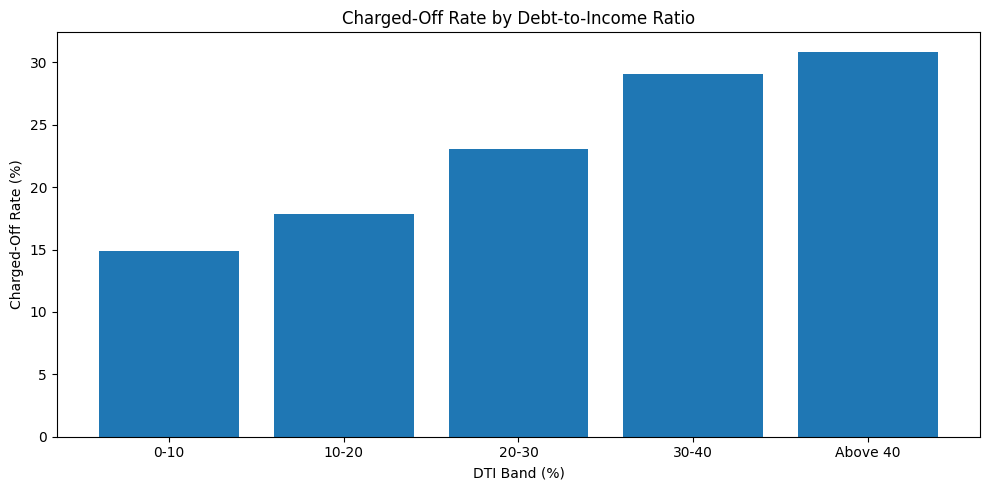

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(
    dti_summary["dti_band"].astype(str),
    dti_summary["Charged_Off_Rate"]
)

plt.title("Charged-Off Rate by Debt-to-Income Ratio")
plt.xlabel("DTI Band (%)")
plt.ylabel("Charged-Off Rate (%)")

plt.tight_layout()
plt.show()

## CREATING AVERAGE FICO SCORE

In [34]:
resolved_loans["fico_score"] = (
    resolved_loans["fico_range_low"] +
    resolved_loans["fico_range_high"]
) / 2

resolved_loans["fico_score"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

count    1.345310e+06
mean     6.981851e+02
std      3.185284e+01
min      6.270000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
90%      7.420000e+02
95%      7.620000e+02
max      8.475000e+02
Name: fico_score, dtype: float64

## CREATING FICO SCORE BANDS

In [35]:
fico_bins = [620, 660, 680, 700, 720, 740, 760, 780, 900]

fico_labels = [
    "620–659",
    "660–679",
    "680–699",
    "700–719",
    "720–739",
    "740–759",
    "760–779",
    "780+"
]

resolved_loans["fico_band"] = pd.cut(
    resolved_loans["fico_score"],
    bins=fico_bins,
    labels=fico_labels,
    right=False
)

# Calculation of loan count, charged-off count, and rate
fico_analysis = resolved_loans.groupby(
    "fico_band", observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

# Converting rate to percentage
fico_analysis["charged_off_rate"] = (
    fico_analysis["charged_off_rate"] * 100
).round(2)

fico_analysis

,fico_band,total_loans,charged_off_loans,charged_off_rate
0,620–659,2,0,0.00
1,660–679,459478,116176,25.28
2,680–699,361326,77458,21.44
3,700–719,246203,42550,17.28
4,720–739,133005,18350,13.80
5,740–759,68309,7619,11.15
6,760–779,38670,3687,9.53
7,780+,38317,2719,7.10


## ANALYZING CHARGED-OFF RATES BY HOME

In [36]:
home_ownership_analysis = resolved_loans.groupby(
    "home_ownership"
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

home_ownership_analysis["charged_off_rate"] = (
    home_ownership_analysis["charged_off_rate"] * 100
).round(2)

home_ownership_analysis.sort_values(
    "charged_off_rate", ascending=False
)

,home_ownership,total_loans,charged_off_loans,charged_off_rate
5,RENT,534421,124074,23.22
4,OWN,144832,29864,20.62
0,ANY,286,56,19.58
3,OTHER,144,27,18.75
1,MORTGAGE,665579,114531,17.21
2,NONE,48,7,14.58


## ANALYZING VERIFICATION STATUS

In [37]:
verification_analysis = resolved_loans.groupby(
    "verification_status"
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

verification_analysis["charged_off_rate"] = (
    verification_analysis["charged_off_rate"] * 100
).round(2)

verification_analysis.sort_values(
    "charged_off_rate", ascending=False
)

,verification_status,total_loans,charged_off_loans,charged_off_rate
2,Verified,418336,99792,23.85
1,Source Verified,521273,109232,20.95
0,Not Verified,405701,59535,14.67


## ANALYZING CHARGED-OFF RATES BY LOAN PURPOSE

In [38]:
purpose_analysis = resolved_loans.groupby(
    "purpose"
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

purpose_analysis["charged_off_rate"] = (
    purpose_analysis["charged_off_rate"] * 100
).round(2)

purpose_analysis.sort_values(
    "charged_off_rate", ascending=False
)

,purpose,total_loans,charged_off_loans,charged_off_rate
11,small_business,15416,4580,29.71
10,renewable_energy,933,221,23.69
8,moving,9480,2214,23.35
5,house,7253,1587,21.88
7,medical,15554,3387,21.78
2,debt_consolidation,780321,165014,21.15
9,other,77875,16385,21.04
12,vacation,9065,1738,19.17
6,major_purchase,29425,5473,18.60
4,home_improvement,87504,15502,17.72


## ANALYZING CHARGED-OFF RATES BY STATE

In [39]:
state_analysis = resolved_loans.groupby(
    "addr_state"
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

state_analysis["charged_off_rate"] = (
    state_analysis["charged_off_rate"] * 100
).round(2)

# Show states with the highest charged-off rates
state_analysis.sort_values(
    "charged_off_rate", ascending=False
)

,addr_state,total_loans,charged_off_loans,charged_off_rate
25,MS,6588,1718,26.08
29,NE,3586,903,25.18
2,AR,10047,2420,24.09
1,AL,16613,3926,23.63
36,OK,12281,2883,23.48
18,LA,15499,3593,23.18
34,NY,109842,24213,22.04
33,NV,20267,4443,21.92
9,FL,95606,20531,21.47
42,TN,20385,4364,21.41


## ANALYZING CHARGED-OFF RATES BY EMPLOYMENT

In [40]:
employment_analysis = resolved_loans.groupby(
    "emp_length",
    dropna=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

employment_analysis["charged_off_rate"] = (
    employment_analysis["charged_off_rate"] * 100
).round(2)

employment_analysis.sort_values(
    "charged_off_rate", ascending=False
)

,emp_length,total_loans,charged_off_loans,charged_off_rate
11,NaN,78511,21130,26.91
0,1 year,88494,18198,20.56
10,< 1 year,108061,22182,20.53
3,3 years,107597,21486,19.97
8,8 years,60701,12100,19.93
9,9 years,50937,10137,19.90
2,2 years,121743,24114,19.81
4,4 years,80556,15900,19.74
5,5 years,84154,16495,19.60
7,7 years,59624,11620,19.49


## ANALYZING CHARGED-OFF RATES BY LOAN AMOUNT

In [41]:
# Checking loan amount distribution
resolved_loans["loan_amnt"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

count    1.345310e+06
mean     1.441997e+04
std      8.717051e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
90%      2.800000e+04
95%      3.287500e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY LOAN AMOUNT

In [42]:
# Defining loan amount bands
loan_bins = [0, 5000, 10000, 15000, 20000, 25000,
             30000, 35000, 40001]

loan_labels = [
    "Below $5K",
    "$5K–10K",
    "$10K–15K",
    "$15K–20K",
    "$20K–25K",
    "$25K–30K",
    "$30K–35K",
    "$35K–40K"
]

resolved_loans["loan_amount_band"] = pd.cut(
    resolved_loans["loan_amnt"],
    bins=loan_bins,
    labels=loan_labels,
    right=False
)

loan_amount_analysis = resolved_loans.groupby(
    "loan_amount_band",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

loan_amount_analysis["charged_off_rate"] = (
    loan_amount_analysis["charged_off_rate"] * 100
).round(2)

loan_amount_analysis

,loan_amount_band,total_loans,charged_off_loans,charged_off_rate
0,Below $5K,133123,20608,15.48
1,$5K–10K,322820,53813,16.67
2,$10K–15K,313326,63859,20.38
3,$15K–20K,213848,47316,22.13
4,$20K–25K,169247,38108,22.52
5,$25K–30K,82748,18162,21.95
6,$30K–35K,49750,12289,24.70
7,$35K–40K,60448,14404,23.83


## ANALYZING CHARGED-OFF RATES BY DELINQUENCY HISTORY

In [43]:
resolved_loans["delinq_2yrs"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.345310e+06
mean     3.177944e-01
std      8.779922e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.000000e+00
95%      2.000000e+00
99%      4.000000e+00
max      3.900000e+01
Name: delinq_2yrs, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY DELINQUENCY GROUP

In [44]:
# Creating delinquency groups
delinq_bins = [-1, 0, 1, 2, np.inf]

delinq_labels = [
    "0 delinquencies",
    "1 delinquency",
    "2 delinquencies",
    "3+ delinquencies"
]

resolved_loans["delinq_group"] = pd.cut(
    resolved_loans["delinq_2yrs"],
    bins=delinq_bins,
    labels=delinq_labels
)

# Calculation of charged-off rates
delinq_analysis = resolved_loans.groupby(
    "delinq_group",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

delinq_analysis["charged_off_rate"] = (
    delinq_analysis["charged_off_rate"] * 100
).round(2)

delinq_analysis

,delinq_group,total_loans,charged_off_loans,charged_off_rate
0,0 delinquencies,1086059,212945,19.61
1,1 delinquency,172317,35899,20.83
2,2 delinquencies,50428,11202,22.21
3,3+ delinquencies,36506,8513,23.32


## ANALYZING CHARGED-OFF RATES BY REVOLVING CREDIT UTILIZATION

In [45]:
resolved_loans["revol_util"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.344453e+06
mean     5.181002e+01
std      2.452107e+01
min      0.000000e+00
25%      3.340000e+01
50%      5.220000e+01
75%      7.070000e+01
90%      8.500000e+01
95%      9.150000e+01
99%      9.820000e+01
max      8.923000e+02
Name: revol_util, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY UTILIZATION GROUP

In [46]:
# Creating a clean subset for utilization analysis
revol_util_analysis = resolved_loans[
    resolved_loans["revol_util"].between(0, 100, inclusive="both")
].copy()

# Defining utilization bands
util_bins = [0, 20, 40, 60, 80, 100.0001]

util_labels = [
    "0–19%",
    "20–39%",
    "40–59%",
    "60–79%",
    "80–100%"
]

revol_util_analysis["util_band"] = pd.cut(
    revol_util_analysis["revol_util"],
    bins=util_bins,
    labels=util_labels,
    right=False
)

# Calculation charged-off rates
util_analysis = revol_util_analysis.groupby(
    "util_band",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

util_analysis["charged_off_rate"] = (
    util_analysis["charged_off_rate"] * 100
).round(2)

util_analysis

,util_band,total_loans,charged_off_loans,charged_off_rate
0,0–19%,153071,22843,14.92
1,20–39%,293955,52793,17.96
2,40–59%,372017,76255,20.50
3,60–79%,327251,71395,21.82
4,80–100%,193472,43846,22.66


## ANALYZING CHARGED-OFF RATES BY PUBLIC RECORD BANKRUPTCIES

In [47]:
resolved_loans["pub_rec"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.345310e+06
mean     2.152760e-01
std      6.018647e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.000000e+00
95%      1.000000e+00
99%      2.000000e+00
max      8.600000e+01
Name: pub_rec, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY PUBLIC RECORD COUNT

In [48]:
# Creating public record groups
pub_rec_bins = [-1, 0, 1, 2, np.inf]

pub_rec_labels = [
    "0 public records",
    "1 public record",
    "2 public records",
    "3+ public records"
]

resolved_loans["pub_rec_group"] = pd.cut(
    resolved_loans["pub_rec"],
    bins=pub_rec_bins,
    labels=pub_rec_labels
)

# Calculation of charged-off rates
pub_rec_analysis = resolved_loans.groupby(
    "pub_rec_group",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

pub_rec_analysis["charged_off_rate"] = (
    pub_rec_analysis["charged_off_rate"] * 100
).round(2)

pub_rec_analysis


,pub_rec_group,total_loans,charged_off_loans,charged_off_rate
0,0 public records,1117425,216705,19.39
1,1 public record,190789,43155,22.62
2,2 public records,24435,5779,23.65
3,3+ public records,12661,2920,23.06


## ANALYZING CHARGED-OFF RATES BY OPEN CREDIT ACCOUNTS

In [49]:
resolved_loans["open_acc"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.345310e+06
mean     1.159352e+01
std      5.473789e+00
min      0.000000e+00
25%      8.000000e+00
50%      1.100000e+01
75%      1.400000e+01
90%      1.900000e+01
95%      2.200000e+01
99%      2.900000e+01
max      9.000000e+01
Name: open_acc, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY OPEN ACCOUNT GROUP

In [50]:
# Defining open account bands
open_acc_bins = [-1, 5, 10, 15, 20, 25, np.inf]

open_acc_labels = [
    "0–5 accounts",
    "6–10 accounts",
    "11–15 accounts",
    "16–20 accounts",
    "21–25 accounts",
    "26+ accounts"
]

resolved_loans["open_acc_group"] = pd.cut(
    resolved_loans["open_acc"],
    bins=open_acc_bins,
    labels=open_acc_labels
)

# Calculation of charged-off rates
open_acc_analysis = resolved_loans.groupby(
    "open_acc_group",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

open_acc_analysis["charged_off_rate"] = (
    open_acc_analysis["charged_off_rate"] * 100
).round(2)

open_acc_analysis

,open_acc_group,total_loans,charged_off_loans,charged_off_rate
0,0–5 accounts,120880,22204,18.37
1,6–10 accounts,539142,103269,19.15
2,11–15 accounts,418840,85592,20.44
3,16–20 accounts,175897,37022,21.05
4,21–25 accounts,61463,13559,22.06
5,26+ accounts,29088,6913,23.77


## ANALYZING CHARGED-OFF RATES BY TOTAL CREDIT ACCOUNTS

In [51]:
resolved_loans["total_acc"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.345310e+06
mean     2.498084e+01
std      1.199847e+01
min      2.000000e+00
25%      1.600000e+01
50%      2.300000e+01
75%      3.200000e+01
90%      4.100000e+01
95%      4.700000e+01
99%      6.100000e+01
max      1.760000e+02
Name: total_acc, dtype: float64

## CALCULATION OF CHARGED-OFF RATES BY TOTAL CREDIT ACCOUNTS

In [52]:
# Defining total credit account bands
total_acc_bins = [0, 10, 20, 30, 40, 50, np.inf]

total_acc_labels = [
    "0–9 accounts",
    "10–19 accounts",
    "20–29 accounts",
    "30–39 accounts",
    "40–49 accounts",
    "50+ accounts"
]

resolved_loans["total_acc_group"] = pd.cut(
    resolved_loans["total_acc"],
    bins=total_acc_bins,
    labels=total_acc_labels,
    right=False
)

# Calculation of charged-off rates
total_acc_analysis = resolved_loans.groupby(
    "total_acc_group",
    observed=False
).agg(
    total_loans=("default_flag", "count"),
    charged_off_loans=("default_flag", "sum"),
    charged_off_rate=("default_flag", "mean")
).reset_index()

total_acc_analysis["charged_off_rate"] = (
    total_acc_analysis["charged_off_rate"] * 100
).round(2)

total_acc_analysis

,total_acc_group,total_loans,charged_off_loans,charged_off_rate
0,0–9 accounts,85140,18178,21.35
1,10–19 accounts,406813,83844,20.61
2,20–29 accounts,441689,86649,19.62
3,30–39 accounts,255351,49062,19.21
4,40–49 accounts,105035,20494,19.51
5,50+ accounts,51282,10332,20.15
